### 1.1 Import Data and required Packages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [7]:
!pip list | grep xgboost

'grep' is not recognized as an internal or external command,
operable program or batch file.


In [4]:
%pip uninstall catboost -y


Note: you may need to restart the kernel to use updated packages.


In [5]:
%pip install catboost --no-cache-dir

   ---------------------------------------- 102.5/102.5 MB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# starting with basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

Import the CSV Data as Pandas DataFrame

In [2]:
df=pd.read_csv(r'stud.csv')

#### Show top 5 records

In [3]:
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

In [4]:
X = df.drop(columns=['math score'], axis=1)

In [11]:
X.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [10]:
# looking at the unique categorical features we have, same code like the EDA notebook.
print("Categories in 'gender' variable: ", end ="")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable: ", end="")
print(df['race/ethnicity'].unique())

print("Categories in 'parental level of education' variable: ", end="")
print(df['parental level of education'].unique())

print("Categories in 'lunch' variable: ", end="")
print(df['lunch'].unique())

print("Categories in 'test preparation course' variable: ", end="")
print(df['test preparation course'].unique())


Categories in 'gender' variable: ['female' 'male']
Categories in 'race_ethnicity' variable: ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variable: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' variable: ['standard' 'free/reduced']
Categories in 'test preparation course' variable: ['none' 'completed']


In [5]:
y = df['math score']

In [7]:
y.head(5)

0    72
1    69
2    90
3    47
4    76
Name: math score, dtype: int64

In [12]:
# Crete column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
        ("StandardScaler", numeric_transformer, num_features),
    ]
)

In [14]:
X = preprocessor.fit_transform(X)

let us see if the the transformation has happened

In [15]:
X

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]])

In [17]:
X.shape

(1000, 19)

that is done well.

Separation into test and train data

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape

((800, 19), (200, 19))

### Creation of an evaluate function to give all the metrics after model training

In [24]:
import numpy as np
def evaluate_model(true, predicted):
    mae= mean_absolute_error(true,predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_square = r2_score(true, predicted)
    return mae, mse, r2_square

In [25]:
models = {
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbours Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(),
    "CatBoosting Regressor": CatBoostRegressor(),
    "AdaBoost Regressor": AdaBoostRegressor(),

}

model_list = []
r2_list = []

for i in range (len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) #this is the training model

    #making the predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # evaluating the train and test dataset
    model_train_mae, model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae, model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model performance for training set")
    print(" - Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print(" - Mean Absolute Error: {:4f}".format(model_train_mae))
    print(" - R2 Score: {:4f}".format(model_train_r2))

    print('-----------------------------------------------')

    print('Model performance for Test Set')
    print(" - Root Mean Squared Errror: {:4f}".format(model_test_rmse))
    print(" - Mean Absolute error: {:4f}".format(model_test_mae))
    print(" - R2 Score: {:4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*30)
    print('\n')


LinearRegression
Model performance for training set
 - Root Mean Squared Error: 28.3485
 - Mean Absolute Error: 4.267109
 - R2 Score: 0.874257
-----------------------------------------------
Model performance for Test Set
 - Root Mean Squared Errror: 29.116679
 - Mean Absolute error: 4.215820
 - R2 Score: 0.880345


Lasso
Model performance for training set
 - Root Mean Squared Error: 43.4784
 - Mean Absolute Error: 5.206303
 - R2 Score: 0.807146
-----------------------------------------------
Model performance for Test Set
 - Root Mean Squared Errror: 42.506417
 - Mean Absolute error: 5.157882
 - R2 Score: 0.825320


Ridge
Model performance for training set
 - Root Mean Squared Error: 28.3378
 - Mean Absolute Error: 4.264988
 - R2 Score: 0.874304
-----------------------------------------------
Model performance for Test Set
 - Root Mean Squared Errror: 29.056272
 - Mean Absolute error: 4.211101
 - R2 Score: 0.880593


K-Neighbours Regressor
Model performance for training set
 - Root Me

Results


In [26]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=['R2_Score'], ascending=False)

,Model Name,R2_Score
2,Ridge,0.880593
0,LinearRegression,0.880345
7,CatBoosting Regressor,0.851632
5,Random Forest Regressor,0.850534
8,AdaBoost Regressor,0.843595
6,XGBRegressor,0.827797
1,Lasso,0.825320
3,K-Neighbours Regressor,0.783497
4,Decision Tree,0.727047


Going to go with Linear Regression as the suited most model

In [29]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print("Accuracy of the Model is %.2f"%score)
print (f"The accuracy of the model is: {round(score,2)}")

Accuracy of the Model is 88.03
The accuracy of the model is: 88.03


Plotting the y_pred and y_test

In [31]:
y_test.shape

(200,)

In [32]:
y_train.shape

(800,)

In [33]:
y_pred.shape

(200,)

Text(0, 0.5, 'Predicted')

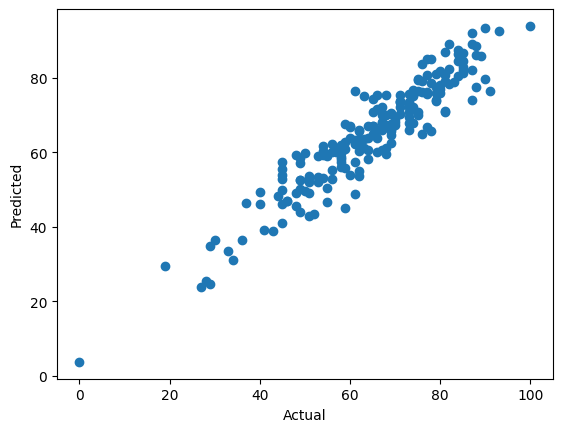

In [35]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual')
plt.ylabel('Predicted')


<Axes: xlabel='math score'>

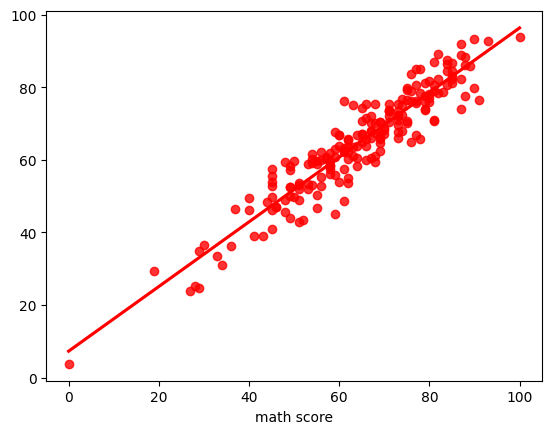

In [36]:
sns.regplot(x=y_test, y=y_pred, ci=None, color='red')

Looking at the difference between Actual and Predicted Values

In [37]:
pred_df = pd.DataFrame({'Actual Value': y_test, 'Predicted Value':y_pred, 'Difference':y_test-y_pred })
pred_df

,Actual Value,Predicted Value,Difference
521,91,76.507812,14.492188
737,53,58.953125,-5.953125
740,80,76.960938,3.039062
660,74,76.757812,-2.757812
411,84,87.539062,-3.539062
...,...,...,...
408,52,43.546875,8.453125
332,62,62.031250,-0.031250
208,74,67.976562,6.023438
613,65,67.132812,-2.132812
